[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/09_data_aggregation/09_6_Pivot_Table.ipynb)

# 09.6: `pivot_table()`: A Different Interface

In notebook 09.2 you built a continent × year table of mean life expectancy using two steps: `groupby(["continent", "year"]).mean()` followed by `unstack("year")`. That two-step approach is flexible and composable, but it produces an unnamed result column and requires you to know about MultiIndex to make sense of the intermediate output.

`pivot_table()` produces the same wide table in a single call with explicit arguments for rows, columns, values, and aggregation function. It is often the faster path when you know from the start that you want a wide layout.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_parquet("gapminder.parquet")
df2007 = df[df["year"] == 2007].copy()
df.head()

## The simplest pivot table

The four core arguments are `values=` (what to aggregate), `index=` (what goes on the rows), `columns=` (what goes on the columns), and `aggfunc=` (how to aggregate). At its simplest, with one grouping dimension and no `columns=`, it behaves like a groupby.

In [2]:
# One grouping dimension: mean life expectancy per continent in 2007
pt = pd.pivot_table(
    df2007,
    values="lifeExp",
    index="continent",
    aggfunc="mean"
).round(1)
pt

,lifeExp
continent,
Africa,54.8
Americas,73.6
Asia,70.7
Europe,77.6
Oceania,80.7


This is the same result as `df2007.groupby("continent")["lifeExp"].mean()`, but returned as a DataFrame with a named index rather than a Series. The difference is minor for one grouping dimension; the advantage of `pivot_table()` becomes visible when you add a second dimension.

## Two grouping dimensions: the full continent × year table

Adding `columns=` creates a two-dimensional table directly, without needing to understand MultiIndex or `unstack()`.

In [3]:
pt2 = pd.pivot_table(
    df,
    values="lifeExp",
    index="continent",
    columns="year",
    aggfunc="mean"
).round(1)
pt2

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007
continent,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7


This is identical to the `groupby(["continent", "year"]).mean().unstack("year")` table from notebook 09.2, but written in one call. Continents are rows, years are columns, and each cell is the mean life expectancy for that continent in that year. Africa's stagnation in the 1990s is visible directly: the 1992 and 1997 values are lower than 1987.

## Multiple aggregation functions

`aggfunc=` accepts a list of functions. The result has a MultiIndex column header, with one level for the function name and one for the value column.

In [4]:
pt3 = pd.pivot_table(
    df2007,
    values="lifeExp",
    index="continent",
    aggfunc=["mean", "min", "max"]
).round(1)
pt3

,mean,min,max
,lifeExp,lifeExp,lifeExp
continent,,,
Africa,54.8,39.6,76.4
Americas,73.6,60.9,80.7
Asia,70.7,43.8,82.6
Europe,77.6,71.8,81.8
Oceania,80.7,80.2,81.2


The column header now has two levels: the aggregation function on top and the value column name below. Reading across a row shows mean, minimum, and maximum for each continent simultaneously. Africa's range from 39.6 to 76.4 is the widest of any continent.

## `margins=True`: row and column totals

The `margins=True` argument adds a grand total row and column. By default the total is labeled `"All"` and uses the same aggregation function as the rest of the table.

In [5]:
pt4 = pd.pivot_table(
    df,
    values="lifeExp",
    index="continent",
    columns="year",
    aggfunc="mean",
    margins=True,
    margins_name="All"
).round(1)
pt4

year,1952,1957,1962,1967,1972,1977,1982,1987,1992,1997,2002,2007,All
continent,,,,,,,,,,,,,
Africa,39.1,41.3,43.3,45.3,47.5,49.6,51.6,53.3,53.6,53.6,53.3,54.8,48.9
Americas,53.3,56.0,58.4,60.4,62.4,64.4,66.2,68.1,69.6,71.2,72.4,73.6,64.7
Asia,46.3,49.3,51.6,54.7,57.3,59.6,62.6,64.9,66.5,68.0,69.2,70.7,60.1
Europe,64.4,66.7,68.5,69.7,70.8,71.9,72.8,73.6,74.4,75.5,76.7,77.6,71.9
Oceania,69.3,70.3,71.1,71.3,71.9,72.9,74.3,75.3,76.9,78.2,79.7,80.7,74.3
All,49.1,51.5,53.6,55.7,57.6,59.6,61.5,63.2,64.2,65.0,65.7,67.0,59.5


The `All` column on the right is each continent's mean across all years. The `All` row at the bottom is the global mean for each year, rising steadily from 49.1 in 1952 to 67.0 in 2007. The bottom-right cell is the global mean across everything: 59.5 years averaged over all countries and all 12 time points.

## A pivot table makes a natural heatmap

A pivot table is a two-dimensional grid of numbers, which is exactly what `sns.heatmap()` expects. Building the pivot table and passing it to the heatmap turns raw Gapminder data into a readable overview in a few lines.

Text(103.75, 0.5, 'Continent')

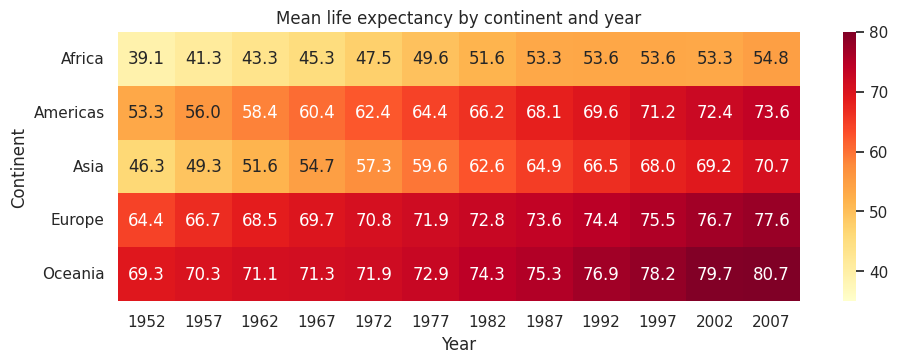

In [6]:
# Use the table without margins for a clean heatmap
heatmap_data = pd.pivot_table(
    df,
    values="lifeExp",
    index="continent",
    columns="year",
    aggfunc="mean"
).round(1)

fig, ax = plt.subplots(figsize=(11, 3.5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    vmin=35, vmax=80,
    ax=ax
)
ax.set_title("Mean life expectancy by continent and year")
ax.set_xlabel("Year")
ax.set_ylabel("Continent")

The heatmap makes every trend in the data visible at once. The color gradient moves from pale yellow (low life expectancy) toward dark red (high life expectancy). Europe and Oceania are dark red throughout. Africa is pale yellow in 1952, brightening through the 1980s, then stalling and slightly darkening in the 1990s before continuing to improve. Asia's rapid improvement shows as a clear color shift from left to right. No chart in module 07 could show five continents across twelve years of two-dimensional aggregated data as compactly as this.

## When to use `pivot_table()` vs `groupby().unstack()`

Both approaches produce the same wide-format aggregated table. The practical difference:

- Use `pivot_table()` when you know from the start that you want a wide layout, want margins, or want to communicate the result to someone who finds the argument names (`index=`, `columns=`, `values=`) more readable than chained method calls.
- Use `groupby().agg().unstack()` when you need a named-aggregation step first (because `pivot_table()` does not support named aggregations), or when you are building the result incrementally and prefer chaining.

Neither is always better. Both belong in your toolkit.

## What's next

You have now covered the full groupby toolkit: single-key and multi-key groupby, `agg()` with named aggregations, `transform()` for group-level columns, `filter()` for group-level conditions, and `pivot_table()` for wide-format summaries. Notebook 09.7 is a set of exercises that ask you to use each of these tools on the Gapminder data.